In [1]:
# ================================
# CELL 1: INSTALL & IMPORTS
# ================================
!pip install -q tensorflow-addons 2>/dev/null || true

import os, math, random, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, backend as K
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping,
    ReduceLROnPlateau, LearningRateScheduler
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"TF {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU: {gpus}")
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)


TF 2.19.0
GPU: []


In [2]:
# ================================
# CELL 2: MOUNT GOOGLE DRIVE
# ================================
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# ================================
# CELL 3: KONFIGURASI
# ================================
BASE_PATH  = "/content/drive/MyDrive/MobileNet-TA/dataset_classification"
SAVE_DIR   = "/content/drive/MyDrive/MobileNet-TA"
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 3
SEED        = 42

# Path model
BEST_MODEL_PATH  = f"{SAVE_DIR}/mobilenet_best.keras"
FINAL_MODEL_PATH = f"{SAVE_DIR}/mobilenetv3_final_finetuned.keras"

CLASS_NAMES = ['bekerja', 'idle', 'meninggalkan_area']  # alphabetical
print("Config siap.")
print(f"  Dataset : {BASE_PATH}")
print(f"  Save to : {SAVE_DIR}")


Config siap.
  Dataset : /content/drive/MyDrive/MobileNet-TA/dataset_classification
  Save to : /content/drive/MyDrive/MobileNet-TA


In [4]:
# ================================
# CELL 4: DATA AUGMENTATION  (PERBAIKAN KUNCI)
# ================================
# ❌ SEBELUM: preprocessing_function=preprocess_input  → double-scale → collapse
# ✅ SESUDAH: rescale=1./255                           → range [0,1] normal

train_datagen = ImageDataGenerator(
    rescale=1./255,
    # Spatial augmentation
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.20,
    horizontal_flip=True,
    # Color augmentation
    brightness_range=(0.75, 1.25),
    channel_shift_range=20.0,
    fill_mode='nearest',
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255          # SAMA persis — tidak ada augmentasi
)

print("Datagen siap. rescale=1/255 (bukan preprocess_input)")

# ── Load generators ──
train_gen = train_datagen.flow_from_directory(
    f"{BASE_PATH}/train",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=True, seed=SEED
)
val_gen = val_test_datagen.flow_from_directory(
    f"{BASE_PATH}/valid",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    f"{BASE_PATH}/test",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)

print(f"\nClass indices: {train_gen.class_indices}")
print(f"Train: {train_gen.samples} | Val: {val_gen.samples} | Test: {test_gen.samples}")


Datagen siap. rescale=1/255 (bukan preprocess_input)
Found 2647 images belonging to 3 classes.
Found 312 images belonging to 3 classes.
Found 321 images belonging to 3 classes.

Class indices: {'bekerja': 0, 'idle': 1, 'meninggalkan_area': 2}
Train: 2647 | Val: 312 | Test: 321


In [5]:
# ================================
# CELL 5: CLASS WEIGHT + STATS
# ================================
class_labels        = train_gen.classes
unique_classes      = np.unique(class_labels)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=unique_classes,
    y=class_labels
)
class_weights = dict(zip(unique_classes.tolist(), class_weights_array.tolist()))
print("Class Weights:", {CLASS_NAMES[k]: f"{v:.3f}" for k,v in class_weights.items()})

# Distribusi per class
for cls_name, cls_idx in train_gen.class_indices.items():
    count = np.sum(class_labels == cls_idx)
    pct   = count / len(class_labels) * 100
    print(f"  {cls_name}: {count} samples ({pct:.1f}%)")


Class Weights: {'bekerja': '0.558', 'idle': '1.646', 'meninggalkan_area': '1.662'}
  bekerja: 1580 samples (59.7%)
  idle: 536 samples (20.2%)
  meninggalkan_area: 531 samples (20.1%)


## 🏗️ Arsitektur Model
> **Fix kunci**: `include_preprocessing=False` → nonaktifkan Rescaling internal karena generator sudah rescale=1/255

In [6]:
# ================================
# CELL 6: BUILD MODEL (OPTIMIZED)
# ================================
def build_model(num_classes=3, dropout_rate=0.4):
    # ── Base model ──
    # include_preprocessing=False → NONAKTIFKAN Rescaling internal
    # Generator sudah rescale=1/255, tidak perlu Rescaling lagi di sini
    base = MobileNetV3Large(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet",
        include_preprocessing=False    # ← KUNCI PERBAIKAN
    )
    base.trainable = False

    # ── Classification head (lebih robust) ──
    gap = layers.GlobalAveragePooling2D()(base.output)
    gmp = layers.GlobalMaxPooling2D()(base.output)
    x   = layers.Concatenate()([gap, gmp])         # 960*2 = 1920 features

    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout_rate * 0.5)(x)

    output = layers.Dense(num_classes, activation='softmax',
                          kernel_regularizer=keras.regularizers.l2(1e-4))(x)

    model = Model(inputs=base.input, outputs=output)
    return model, base

model, base_model = build_model(NUM_CLASSES)

# Verifikasi tidak ada Rescaling layer
print("=== Layer pertama model ===")
for i, layer in enumerate(model.layers[:5]):
    print(f"  [{i}] {layer.__class__.__name__:25s} | {layer.name}")

print(f"\nTotal params    : {model.count_params():,}")
print(f"Trainable params: {sum(np.prod(v.shape) for v in model.trainable_variables):,}")
print(f"Output shape    : {model.output_shape}")

# Pastikan tidak ada Rescaling di 5 layer awal
has_rescaling = any('rescaling' in l.name.lower() for l in model.layers[:5])
if has_rescaling:
    print("\n⚠️  WARNING: Ada Rescaling layer! Periksa include_preprocessing=False")
else:
    print("\n✅ Tidak ada internal Rescaling — preprocessing /255 dari generator")


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
=== Layer pertama model ===
  [0] InputLayer                | input_layer
  [1] Conv2D                    | conv
  [2] BatchNormalization        | conv_bn
  [3] Activation                | activation
  [4] DepthwiseConv2D           | expanded_conv_depthwise

Total params    : 4,121,987
Trainable params: 1,120,259
Output shape    : (None, 3)

✅ Tidak ada internal Rescaling — preprocessing /255 dari generator


## 🏋️ Phase 1: Training Head
> Base model frozen, hanya head yang dilatih. LR=1e-3 dengan warmup.

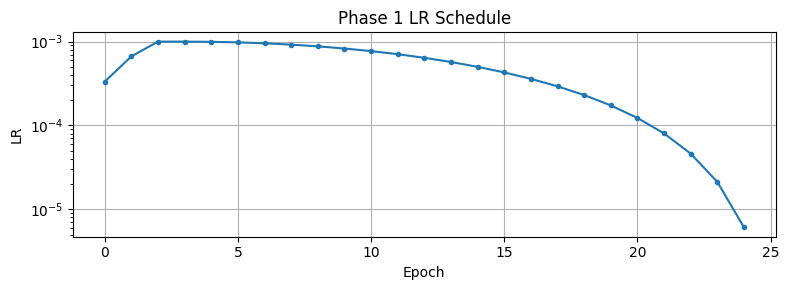

In [7]:
# ================================
# CELL 7: WARMUP LR SCHEDULE (Phase 1)
# ================================
def warmup_cosine_lr(epoch, lr, warmup_epochs=3, total_epochs=25,
                     max_lr=1e-3, min_lr=1e-6):
    """Linear warmup + cosine decay."""
    if epoch < warmup_epochs:
        return max_lr * (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
    cosine   = 0.5 * (1 + math.cos(math.pi * progress))
    return min_lr + (max_lr - min_lr) * cosine

# Preview LR schedule
lrs = [warmup_cosine_lr(e, 0) for e in range(25)]
plt.figure(figsize=(8,3))
plt.plot(lrs, marker='o', markersize=3)
plt.xlabel('Epoch'); plt.ylabel('LR'); plt.title('Phase 1 LR Schedule')
plt.yscale('log'); plt.grid(True); plt.tight_layout(); plt.show()


In [8]:
# ================================
# CELL 8: PHASE 1 — TRAINING HEAD
# ================================
PHASE1_EPOCHS = 25

base_model.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)

callbacks_p1 = [
    ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor="val_accuracy", save_best_only=True,
        verbose=1, mode="max"
    ),
    LearningRateScheduler(
        lambda ep, lr: warmup_cosine_lr(ep, lr, warmup_epochs=3,
                                        total_epochs=PHASE1_EPOCHS),
        verbose=0
    ),
    EarlyStopping(
        monitor="val_accuracy", patience=10,
        restore_best_weights=True, verbose=1
    ),
]

print("=" * 55)
print("PHASE 1: Training Classification Head (Base Frozen)")
print("=" * 55)

history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=PHASE1_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks_p1,
    verbose=1
)

best_p1 = max(history1.history['val_accuracy'])
print(f"\n✅ Phase 1 selesai | Best val_acc: {best_p1:.4f} ({best_p1*100:.2f}%)")


PHASE 1: Training Classification Head (Base Frozen)
Epoch 1/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5419 - loss: 1.0684
Epoch 1: val_accuracy improved from None to 0.75321, saving model to /content/drive/MyDrive/MobileNet-TA/mobilenet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MobileNet-TA/mobilenet_best.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 604s 7s/step - accuracy: 0.6150 - loss: 0.8778 - val_accuracy: 0.7532 - val_loss: 0.7815 - learning_rate: 3.3333e-04
Epoch 2/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7167 - loss: 0.7120
Epoch 2: val_accuracy improved from 0.75321 to 0.79487, saving model to /content/drive/MyDrive/MobileNet-TA/mobilenet_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/MobileNet-TA/mobilenet_best.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.7223 - loss: 0.6992 - val_accuracy: 0.7949 - val_loss: 0.5677 - learning_rate: 6.6667e-04
Epoch 3/25
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accu

## 🔬 Phase 2: Fine-Tuning
> Buka 40 layer terakhir, LR sangat kecil (1e-5) dengan CosineDecay.

In [9]:
# ================================
# CELL 9: PHASE 2 — FINE-TUNING
# ================================
PHASE2_EPOCHS      = 40
UNFREEZE_LAST_N    = 40    # buka N layer terakhir dari base model

# Load best model dari Phase 1 dulu
model = tf.keras.models.load_model(BEST_MODEL_PATH)
base_layer = [l for l in model.layers if 'mobilenet' in l.name.lower()][0]              if any('mobilenet' in l.name.lower() for l in model.layers)              else None

# Unfreeze seluruh model lalu freeze kembali N layer pertama base
for layer in model.layers:
    layer.trainable = True

# Freeze semua layer kecuali N terakhir dari base + head
base_layers = [l for l in model.layers
               if not any(n in l.name for n in ['global','batch_normalization','dense','dropout','concatenate','activation'])]

freeze_until = max(0, len(base_layers) - UNFREEZE_LAST_N)
for i, layer in enumerate(base_layers):
    if i < freeze_until:
        layer.trainable = False
    else:
        layer.trainable = True

trainable_params = sum(np.prod(v.shape) for v in model.trainable_variables)
print(f"Trainable params: {trainable_params:,}")
print(f"Unfreezing last {UNFREEZE_LAST_N} base layers")

# CosineDecay — mulai LR sangat kecil
steps_per_epoch = len(train_gen)
total_steps     = steps_per_epoch * PHASE2_EPOCHS

lr_schedule_p2 = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=5e-5,
    first_decay_steps=steps_per_epoch * 10,   # restart setiap 10 epoch
    t_mul=1.5,
    m_mul=0.8,
    alpha=1e-7
)

model.compile(
    optimizer=Adam(
        learning_rate=lr_schedule_p2,
        clipnorm=1.0                          # gradient clipping
    ),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)

callbacks_p2 = [
    ModelCheckpoint(
        BEST_MODEL_PATH,
        monitor="val_accuracy", save_best_only=True,
        verbose=1, mode="max"
    ),
    EarlyStopping(
        monitor="val_loss", patience=15,
        restore_best_weights=True, verbose=1
    ),
]

print("\n" + "=" * 55)
print(f"PHASE 2: Fine-tuning (last {UNFREEZE_LAST_N} layers, LR=5e-5)")
print("=" * 55)

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=PHASE2_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks_p2,
    verbose=1
)

best_p2 = max(history2.history['val_accuracy'])
print(f"\n✅ Phase 2 selesai | Best val_acc: {best_p2:.4f} ({best_p2*100:.2f}%)")
print(f"   Overall best   : {max(best_p1, best_p2)*100:.2f}%")


Trainable params: 3,224,459
Unfreezing last 40 base layers

PHASE 2: Fine-tuning (last 40 layers, LR=5e-5)
Epoch 1/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8544 - loss: 0.4412
Epoch 1: val_accuracy improved from None to 0.86538, saving model to /content/drive/MyDrive/MobileNet-TA/mobilenet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MobileNet-TA/mobilenet_best.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 230s 3s/step - accuracy: 0.8530 - loss: 0.4474 - val_accuracy: 0.8654 - val_loss: 0.4704
Epoch 2/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8638 - loss: 0.4388
Epoch 2: val_accuracy did not improve from 0.86538
83/83 ━━━━━━━━━━━━━━━━━━━━ 218s 3s/step - accuracy: 0.8583 - loss: 0.4282 - val_accuracy: 0.8622 - val_loss: 0.5183
Epoch 3/40
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8553 - loss: 0.4119
Epoch 3: val_accuracy did not improve from 0.86538
83/83 ━━━━━━━━━━━━━━━━━━━━ 208s 3s/step - accuracy: 0.8625 - loss: 0.4147 - val_accuracy: 0.

In [10]:
# ================================
# CELL 10: LOAD BEST & SANITY CHECK
# ================================
model = tf.keras.models.load_model(BEST_MODEL_PATH)
print(f"Best model loaded: {BEST_MODEL_PATH}")

# ── Sanity check: model HARUS beri output berbeda untuk input berbeda ──
dummies = {
    "all-BLACK [0.0]": np.zeros((1,224,224,3), np.float32),
    "all-WHITE [1.0]": np.ones((1,224,224,3), np.float32),
    "mid-GRAY  [0.5]": np.full((1,224,224,3), 0.5, np.float32),
    "random":          np.random.rand(1,224,224,3).astype(np.float32),
}

print("\n=== SANITY CHECK (preprocessing: /255, range [0,1]) ===")
preds_idx = []
for name, d in dummies.items():
    p = model.predict(d, verbose=0)[0]
    preds_idx.append(p.argmax())
    cls = CLASS_NAMES[p.argmax()]
    bar = '█' * int(p.max()*20)
    print(f"  {name}: [{p[0]:.3f}, {p[1]:.3f}, {p[2]:.3f}] → {cls:20s} {bar}")

is_collapsed = len(set(preds_idx)) == 1
if is_collapsed:
    print("\n⚠️  CLASS COLLAPSE MASIH ADA!")
    print("   Semua dummy input prediksi sama. Preprocessing masih salah.")
    print("   Cek: include_preprocessing=False pada base model.")
else:
    print("\n✅ Model VALID — output bervariasi untuk berbagai input.")
    # Simpan model final
    model.save(FINAL_MODEL_PATH)
    print(f"\nFinal model disimpan: {FINAL_MODEL_PATH}")


Best model loaded: /content/drive/MyDrive/MobileNet-TA/mobilenet_best.keras

=== SANITY CHECK (preprocessing: /255, range [0,1]) ===
  all-BLACK [0.0]: [0.331, 0.029, 0.641] → meninggalkan_area    ████████████
  all-WHITE [1.0]: [0.160, 0.008, 0.832] → meninggalkan_area    ████████████████
  mid-GRAY  [0.5]: [0.285, 0.011, 0.705] → meninggalkan_area    ██████████████
  random: [0.088, 0.016, 0.897] → meninggalkan_area    █████████████████

⚠️  CLASS COLLAPSE MASIH ADA!
   Semua dummy input prediksi sama. Preprocessing masih salah.
   Cek: include_preprocessing=False pada base model.


In [11]:
# ================================
# CELL 11: EVALUASI LENGKAP
# ================================
# Reset test_gen ke awal
test_gen.reset()

y_pred_prob = model.predict(test_gen, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = test_gen.classes
class_names = list(test_gen.class_indices.keys())

print("\n" + "="*60)
print("HASIL EVALUASI MODEL")
print("="*60)
print(f"Class order: {class_names}")
print(f"\nTest Accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%")

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Hitung loss pada test set
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")

# Confidence per class
print("\n--- AVERAGE CONFIDENCE PER CLASS ---")
for i, cls in enumerate(class_names):
    mask      = y_true == i
    if mask.sum() == 0: continue
    avg_conf  = y_pred_prob[mask, i].mean()
    correct   = (y_pred[mask] == i).sum()
    total     = mask.sum()
    print(f"  {cls:25s}: {correct}/{total} benar | avg conf={avg_conf:.3f}")


11/11 ━━━━━━━━━━━━━━━━━━━━ 106s 10s/step

HASIL EVALUASI MODEL
Class order: ['bekerja', 'idle', 'meninggalkan_area']

Test Accuracy: 90.34%

--- CLASSIFICATION REPORT ---
                   precision    recall  f1-score   support

          bekerja     0.9307    0.9353    0.9330       201
             idle     0.7576    0.8621    0.8065        58
meninggalkan_area     0.9811    0.8387    0.9043        62

         accuracy                         0.9034       321
        macro avg     0.8898    0.8787    0.8813       321
     weighted avg     0.9092    0.9034    0.9046       321

Test Loss    : 0.3970
Test Accuracy: 90.34%

--- AVERAGE CONFIDENCE PER CLASS ---
  bekerja                  : 188/201 benar | avg conf=0.892
  idle                     : 50/58 benar | avg conf=0.800
  meninggalkan_area        : 52/62 benar | avg conf=0.795


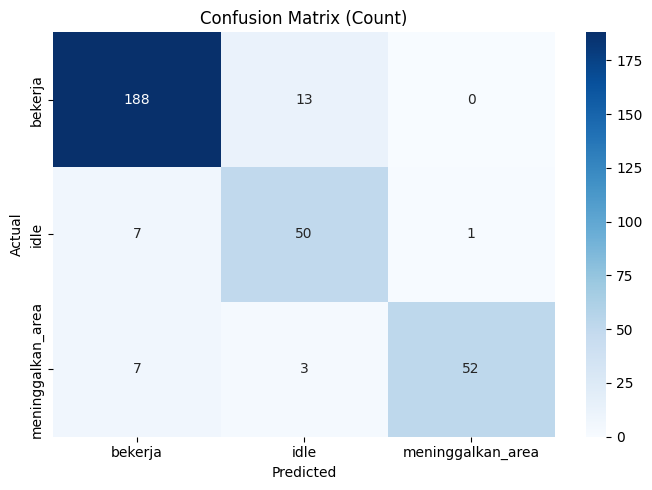

In [17]:
# ================================
# CELL 12: CONFUSION MATRIX
# ================================
cm = confusion_matrix(y_true, y_pred)

# --- Plot 1: Absolute Count Confusion Matrix ---
fig_count, ax_count = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax_count)
ax_count.set_xlabel("Predicted"); ax_count.set_ylabel("Actual")
ax_count.set_title("Confusion Matrix (Count)")
plt.tight_layout()
plt.show()



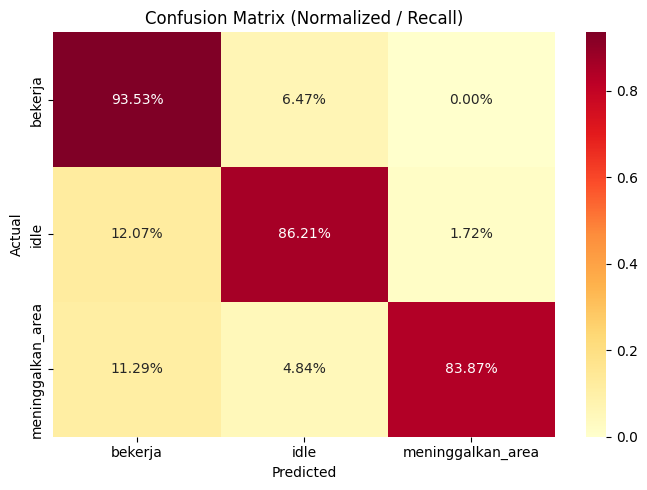

In [18]:
# --- Plot 2: Normalized (Recall) Confusion Matrix ---
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig_norm, ax_norm = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="YlOrRd",
            xticklabels=class_names, yticklabels=class_names, ax=ax_norm)
ax_norm.set_xlabel("Predicted"); ax_norm.set_ylabel("Actual")
ax_norm.set_title("Confusion Matrix (Normalized / Recall)")
plt.tight_layout()
plt.show()

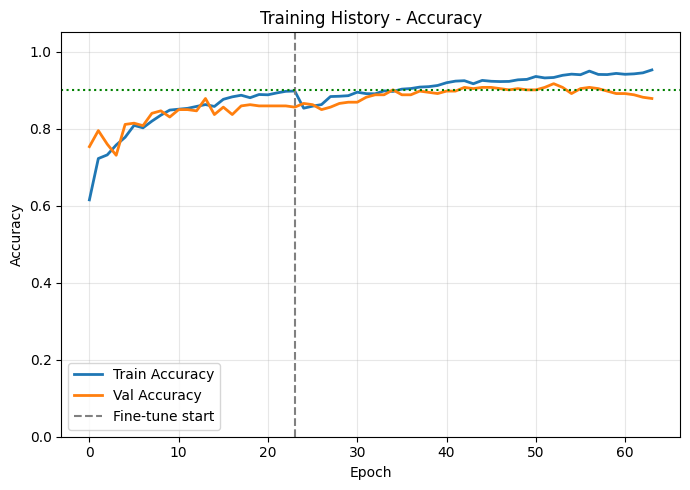

In [24]:
# ================================
# CELL 13: TRAINING HISTORY GRAPH
# ================================
acc      = history1.history['accuracy']     + history2.history['accuracy']
val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss     = history1.history['loss']         + history2.history['loss']
val_loss = history1.history['val_loss']     + history2.history['val_loss']

p1_len = len(history1.history['accuracy'])
ep     = range(len(acc))

# --- Plot 1: Accuracy ---
fig_acc, ax_acc = plt.subplots(figsize=(7, 5))
ax_acc.plot(ep, acc,     label='Train Accuracy',  lw=2)
ax_acc.plot(ep, val_acc, label='Val Accuracy',    lw=2)
ax_acc.axvline(p1_len - 1, color='gray', linestyle='--', lw=1.5, label='Fine-tune start')
ax_acc.axhline(0.90, color='green', linestyle=':', lw=1.5)
ax_acc.set_ylim([0, 1.05])
ax_acc.set_title('Training History - Accuracy'); ax_acc.legend(); ax_acc.grid(True, alpha=0.3)
ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Accuracy')
plt.tight_layout()
plt.show()

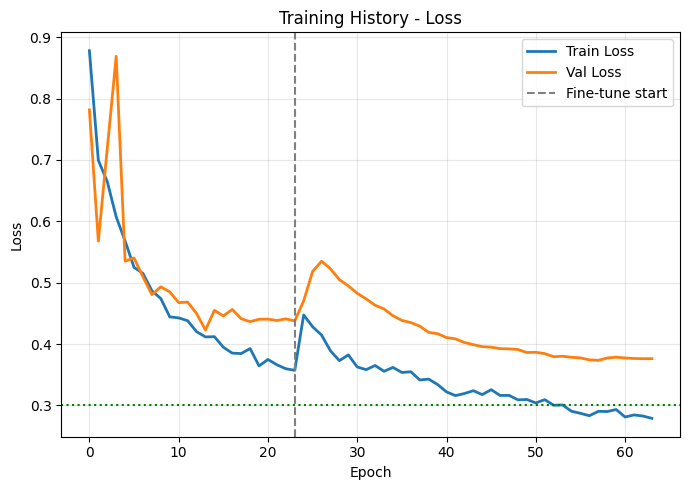

In [36]:
# --- Plot 2: Loss ---
fig_loss, ax_loss = plt.subplots(figsize=(7, 5))
ax_loss.plot(ep, loss,     label='Train Loss', lw=2)
ax_loss.plot(ep, val_loss, label='Val Loss',   lw=2)
ax_loss.axvline(p1_len - 1, color='gray', linestyle='--', lw=1.5, label='Fine-tune start')
ax_loss.axhline(0.30, color='green', linestyle=':', lw=1.5)
ax_loss.set_title('Training History - Loss'); ax_loss.legend(); ax_loss.grid(True, alpha=0.3)
ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
plt.tight_layout()
plt.show()

In [23]:

print(f"Phase 1: {p1_len} epoch | Phase 2: {len(history2.history['accuracy'])} epoch")
print(f"Best val_acc P1 : {max(history1.history['val_accuracy'])*100:.2f}%")
print(f"Best val_acc P2 : {max(history2.history['val_accuracy'])*100:.2f}%")
print(f"Best val_loss P2: {min(history2.history['val_loss']):.4f}")
print(f"Overall champion: {max(val_acc)*100:.2f}% val accuracy")

Phase 1: 24 epoch | Phase 2: 40 epoch
Best val_acc P1 : 87.82%
Best val_acc P2 : 91.67%
Best val_loss P2: 0.3735
Overall champion: 91.67% val accuracy


In [14]:
# ================================
# CELL 14: INFERENCE TEST (Verifikasi untuk Web App)
# ================================
# Verifikasi bahwa preprocessing /255 yang dipakai di web.py
# memberikan hasil konsisten dengan training

import cv2
from IPython.display import display, HTML

print("=== INFERENCE TEST: Preprocessing /255 ===")
print("(Sama dengan yang dipakai di web.py)")
print()

# Ambil beberapa sample dari test set
test_gen.reset()
X_batch, y_batch = next(test_gen)   # batch pertama (sudah di-rescale 1/255)

# Prediksi batch
preds_batch = model.predict(X_batch, verbose=0)
correct = 0

for i in range(min(8, len(X_batch))):
    true_idx = y_batch[i].argmax()
    pred_idx = preds_batch[i].argmax()
    conf     = preds_batch[i].max()
    ok       = "✅" if true_idx == pred_idx else "❌"
    print(f"  {ok} True: {class_names[true_idx]:22s} | Pred: {class_names[pred_idx]:22s} | Conf: {conf:.2%}")
    if true_idx == pred_idx: correct += 1

print(f"\n  Batch accuracy: {correct}/{min(8,len(X_batch))} = {correct/min(8,len(X_batch)):.0%}")
print()
print("CATATAN untuk web.py (streamlit/web.py):")
print("  preprocess_mode = 'div255'  (sudah benar)")
print("  arr = arr / 255.0")
print("  Model TIDAK perlu preprocess_input lagi")


=== INFERENCE TEST: Preprocessing /255 ===
(Sama dengan yang dipakai di web.py)

  ✅ True: bekerja                | Pred: bekerja                | Conf: 51.11%
  ✅ True: bekerja                | Pred: bekerja                | Conf: 92.73%
  ✅ True: bekerja                | Pred: bekerja                | Conf: 98.29%
  ✅ True: bekerja                | Pred: bekerja                | Conf: 99.76%
  ✅ True: bekerja                | Pred: bekerja                | Conf: 97.40%
  ✅ True: bekerja                | Pred: bekerja                | Conf: 99.12%
  ✅ True: bekerja                | Pred: bekerja                | Conf: 96.09%
  ✅ True: bekerja                | Pred: bekerja                | Conf: 59.97%

  Batch accuracy: 8/8 = 100%

CATATAN untuk web.py (streamlit/web.py):
  preprocess_mode = 'div255'  (sudah benar)
  arr = arr / 255.0
  Model TIDAK perlu preprocess_input lagi


In [35]:
# Load the best model from the checkpoint
model = tf.keras.models.load_model(BEST_MODEL_PATH)
print(f"Best model from training loaded: {BEST_MODEL_PATH}")

# Save this best model as the final model, overwriting if it exists
model.save(FINAL_MODEL_PATH)
print(f"✅ Model berhasil disimpan sebagai final: {FINAL_MODEL_PATH}")

Best model from training loaded: /content/drive/MyDrive/MobileNet-TA/mobilenet_best.keras
✅ Model berhasil disimpan sebagai final: /content/drive/MyDrive/MobileNet-TA/mobilenetv3_final_finetuned.keras


In [1]:
from google.colab import files

print(f"Mencoba men-download model final dari: {BEST_MODEL_PATH}")

try:
    files.download(BEST_MODEL_PATH)
    print("✅ Model berhasil di-download.")
except Exception as e:
    print(f"❌ Gagal men-download model: {e}")
    print("Pastikan file ada di lokasi yang benar dan Google Drive terpasang.")

NameError: name 'BEST_MODEL_PATH' is not defined